# Customer Churn Prediction

## Project Overview

Customer churn refers to when a customer stops using a company's product or service. In highly competitive industries such as telecommunications, customer retention is critical because acquiring new customers is often significantly more expensive than retaining existing ones.

The objective of this project is to build machine learning models that can predict whether a customer will churn based on their demographic information, account details, and service usage patterns.

By identifying customers at risk of churning, telecom companies can implement targeted retention strategies such as personalized offers, service improvements, or loyalty incentives.

### Goals of the Project

• Perform exploratory data analysis to understand churn behavior  
• Prepare and preprocess the dataset for machine learning models  
• Train classification models to predict customer churn  
• Evaluate model performance using standard classification metrics  
• Identify the most important features influencing churn  

### Models Implemented

- Logistic Regression (baseline model)
- Random Forest (ensemble model)

### Evaluation Metrics

Since churn datasets are typically imbalanced, multiple evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1 Score

In [19]:
#IMPORTING LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [20]:
#LOADING DATASET

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Loading the Dataset

The dataset used in this project is the **Telco Customer Churn Dataset**, which contains information about telecom customers and whether they discontinued their service.

The dataset includes features such as:

- Customer tenure
- Contract type
- Monthly charges
- Internet service type
- Payment method

The target variable is **Churn**, which indicates whether the customer left the service.

In [21]:
df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

Real-world datasets often contain missing values or inconsistent data types.  
Before training machine learning models, we perform the following cleaning steps:

1. Convert the **TotalCharges** column to numeric format
2. Remove rows containing missing values
3. Remove the **customerID** column since it is only a unique identifier and does not contribute predictive value

In [22]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df = df.drop("customerID", axis=1)

## Exploratory Data Analysis (EDA)

Exploratory data analysis helps us understand patterns within the data and identify relationships between features and customer churn.

In this section we visualize:

- Overall churn distribution
- Churn rates across contract types
- Relationship between tenure and churn
- Monthly charges vs churn

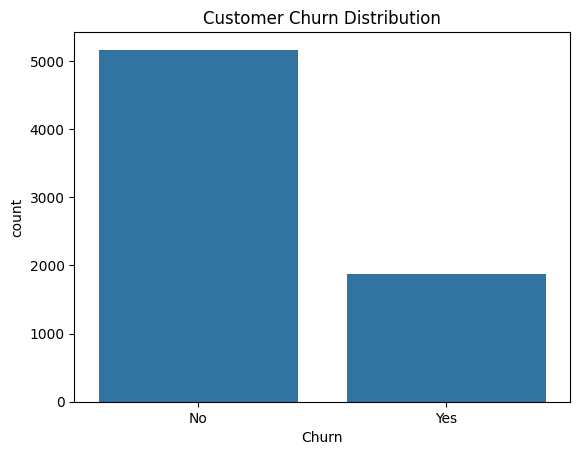

In [23]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

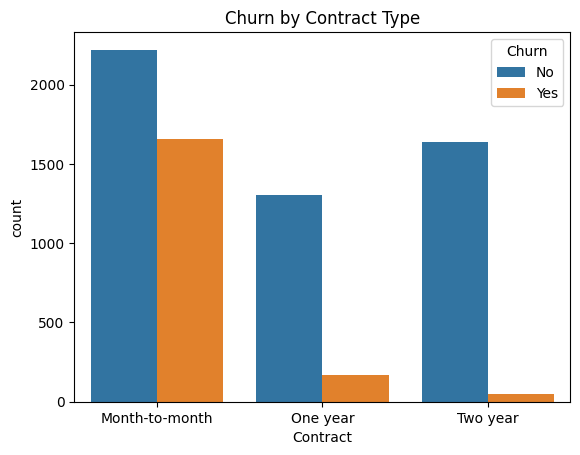

In [24]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

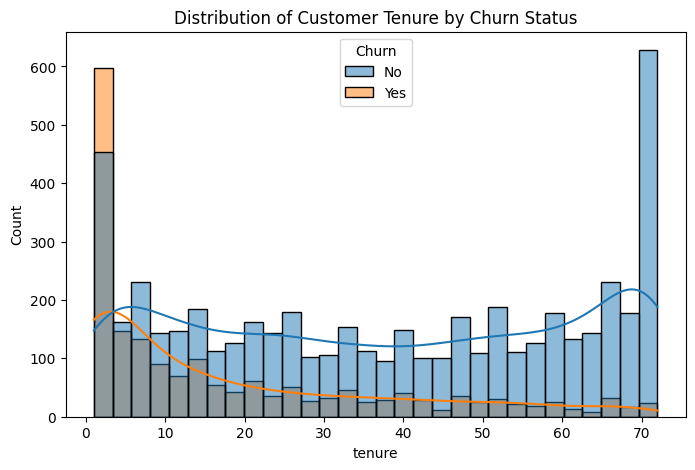

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Distribution of Customer Tenure by Churn Status")
plt.show()

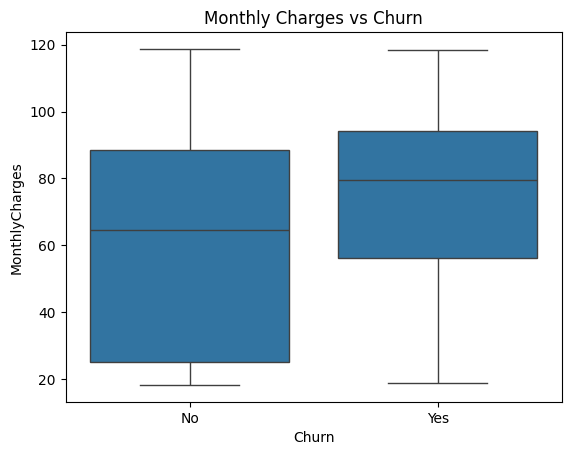

In [26]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Key Observations from EDA

Several patterns emerge from the exploratory analysis:

• Customers on **month-to-month contracts** show significantly higher churn rates.

• Customers with **shorter tenure** are more likely to churn compared to long-term customers.

• Customers with **higher monthly charges** appear to have a slightly higher probability of churn.

These patterns suggest that contract commitment and pricing play important roles in customer retention.

## Feature Engineering

Machine learning models require numerical inputs. Since the dataset contains categorical variables such as contract type and payment method, we convert these into numerical features using **one-hot encoding**.

In [27]:
df = pd.get_dummies(df, drop_first=True)

## Defining Features and Target Variable

The dataset is divided into:

- **Features (X)** → input variables used to predict churn  
- **Target (y)** → churn outcome

In [28]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

## Train-Test Split

To evaluate model performance objectively, the dataset is divided into:

- **Training set (80%)** → used to train the model  
- **Test set (20%)** → used to evaluate the model

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

Logistic regression is sensitive to the scale of input features.  
Therefore, numerical features are standardized using **StandardScaler**.

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic regression is used as the baseline model because it is simple, interpretable, and widely used for binary classification problems.

In [31]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Random Forest Model

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.

It is often more powerful than simple models because it captures nonlinear relationships in the data.

In [32]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## ROC-AUC Evaluation

Accuracy alone can be misleading when evaluating classification models on imbalanced datasets such as customer churn.

The **ROC-AUC score** measures how well the model distinguishes between churn and non-churn customers across different classification thresholds.

A higher ROC-AUC score indicates better model performance.

In [ ]:
#Logistic Regression ROC-AUC
y_prob_lr = model.predict_proba(X_test_scaled)[:,1]

roc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", roc_lr)

Logistic Regression ROC-AUC: 0.8319235288940887


In [37]:
#Random Forest ROC-AUC
y_prob_rf = rf.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.8189518613042329


### Model Performance Comparison

The ROC-AUC score for Logistic Regression was slightly higher than for the Random Forest model.

This suggests that Logistic Regression is better at distinguishing between churn and non-churn customers across different probability thresholds.

One possible explanation is that the relationship between the features and churn may be largely linear, allowing logistic regression to perform competitively with more complex models.

This highlights the importance of comparing multiple models, as simpler models can sometimes perform as well as or better than more complex alternatives.

## ROC Curve

The ROC curve visualizes the trade-off between the **true positive rate (recall)** and the **false positive rate** across different decision thresholds.

Models with curves closer to the top-left corner demonstrate stronger classification performance.

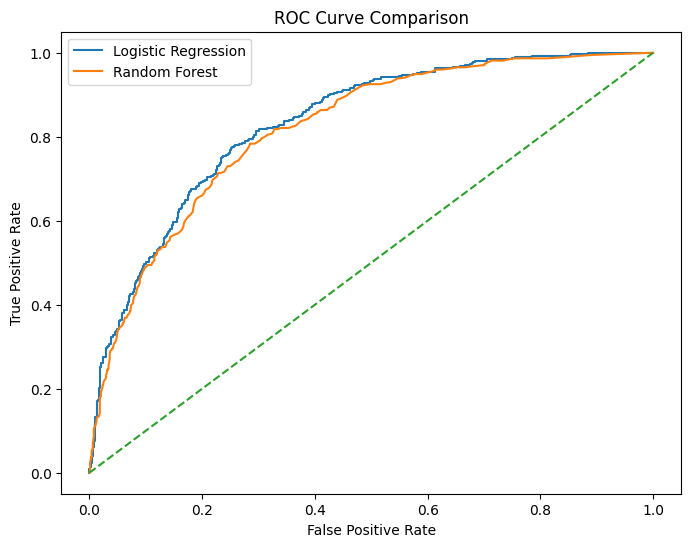

In [38]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

## Confusion Matrix

The confusion matrix provides a detailed breakdown of classification performance by showing:

- True positives
- True negatives
- False positives
- False negatives

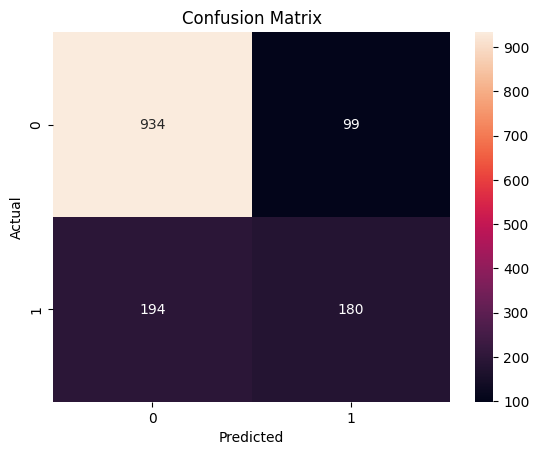

In [33]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

Random Forest models provide estimates of feature importance, which helps identify the variables that most strongly influence churn prediction.

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.195802
2,MonthlyCharges,0.168231
1,tenure,0.167302
10,InternetService_Fiber optic,0.038661
28,PaymentMethod_Electronic check,0.035773
25,Contract_Two year,0.029693
4,gender_Male,0.027900
13,OnlineSecurity_Yes,0.027197
26,PaperlessBilling_Yes,0.024655
19,TechSupport_Yes,0.024462


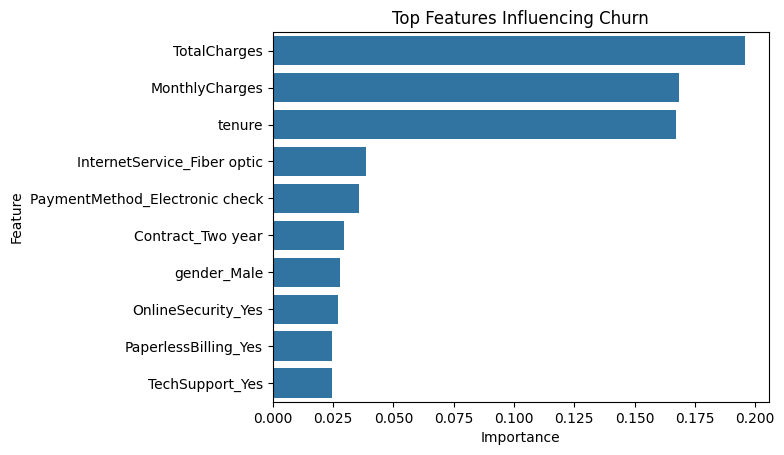

In [35]:
sns.barplot(x="Importance", y="Feature", data=importance.head(10))
plt.title("Top Features Influencing Churn")
plt.show()

## Business Insights

The analysis reveals several important drivers of customer churn:

• Customers with **month-to-month contracts** have the highest churn risk.

• Customers with **short tenure** are more likely to discontinue service.

• **Higher monthly charges** appear to increase churn probability.

These insights suggest telecom companies could reduce churn by encouraging longer-term contracts and targeting high-risk customers with retention offers.

## Identifying High-Risk Customers

Instead of only predicting churn as a binary outcome, machine learning models also produce a probability score representing the likelihood that a customer will churn.

These probability scores allow companies to identify **high-risk customers** and prioritize retention efforts accordingly.

In [40]:
churn_probabilities = rf.predict_proba(X_test)[:,1]

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Probability": churn_probabilities
})

results.head()

,Actual,Predicted_Probability
2481,False,0.000
6784,False,0.080
6125,True,0.570
3052,False,0.080
4099,False,0.265


In [41]:
high_risk = results.sort_values(by="Predicted_Probability", ascending=False)

high_risk.head(10)

,Actual,Predicted_Probability
1731,True,1.000000
1976,True,1.000000
684,False,1.000000
6933,True,0.997500
6924,True,0.995000
6488,True,0.992500
6495,True,0.990833
3771,True,0.985000
2194,True,0.985000
6368,True,0.980000


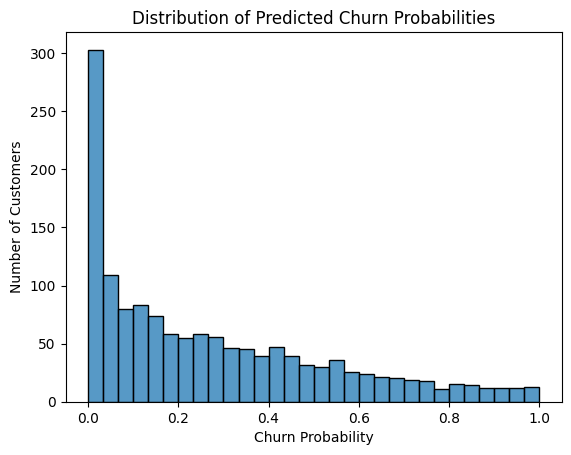

In [42]:
sns.histplot(churn_probabilities, bins=30)

plt.title("Distribution of Predicted Churn Probabilities")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")

plt.show()

### Insight

The model assigns churn probabilities across a wide range of values. Customers with very high predicted probabilities represent the most at-risk group.

Telecom companies could use this information to design targeted retention campaigns aimed at these high-risk customers.

## Conclusion

In this project, machine learning models were developed to predict telecom customer churn.

Key findings include:

- Logistic Regression and Random Forest models achieved approximately **79% accuracy**
- Contract type, tenure, and monthly charges were identified as key churn predictors

Future work could include:

- Hyperparameter tuning
- Gradient boosting models such as XGBoost
- Cross-validation for improved model reliability